E-commerce Data Analysis Project

This project analyzes an e-commerce dataset to understand sales, customers, and delivery performance.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
import seaborn as sns
import zipfile

## 1. Data Loading

We load multiple datasets from the Olist e-commerce database.

In [16]:
path = "/Users/imacfamilebouziane/Downloads/cmort/"

orders = pd.read_csv(path + "olist_orders_dataset.csv")
items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
geo = pd.read_csv(path + "olist_geolocation_dataset.csv")

## 2. Data Integration

We merge all tables into a single dataset using order_id and customer_id.

In [21]:
df = orders.merge(customers, on="customer_id") \
           .merge(items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(payments, on="order_id") \
           .merge(reviews, on="order_id")

## 3. Feature Engineering

We create new variables such as month, delivery time, and late delivery flag.

In [22]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

df['delivery_time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    df['order_purchase_timestamp']
).dt.days

## 4. Key Performance Indicators

We compute business metrics such as revenue, number of orders, and average basket size.

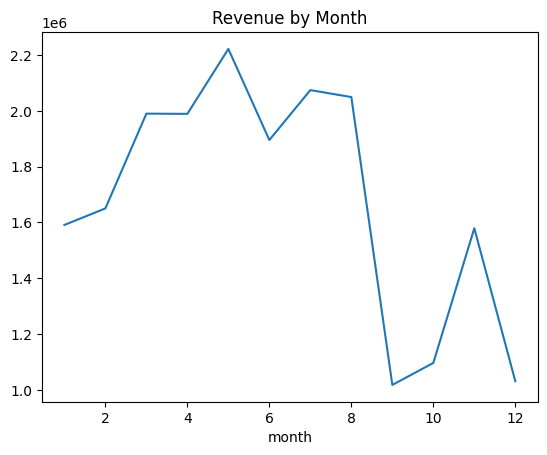

In [30]:
df.groupby('month')['payment_value'].sum().plot()
plt.title("Revenue by Month")
plt.show()

In [31]:
orders.shape, customers.shape, items.shape

((99441, 8), (99441, 5), (112650, 7))

In [57]:
df = orders.merge(customers, on="customer_id") \
           .merge(items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(payments, on="order_id") \
           .merge(reviews, on="order_id")



In [34]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [ ]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [ ]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [ ]:
df['is_late'] = df['delivery_time'] > 7

In [35]:
df['payment_value'].sum()

np.float64(20187928.7)

In [36]:
df['order_id'].nunique()

97916

In [37]:
df['payment_value'].sum() / df['order_id'].nunique()

np.float64(206.17599473017688)

In [39]:
df[['order_delivered_customer_date', 'order_purchase_timestamp']].isnull().sum()

order_delivered_customer_date    2471
order_purchase_timestamp            0
dtype: int64

In [40]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

In [41]:
df_clean = df.dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date'])

In [42]:
df_clean['delivery_time'] = (
    df_clean['order_delivered_customer_date'] - df_clean['order_purchase_timestamp']
).dt.days

In [43]:
df_clean['is_late'] = df_clean['delivery_time'] > 7

late_rate = df_clean['is_late'].mean()
late_rate

np.float64(0.64914938445733)

In [44]:
df_clean[['delivery_time']].describe()

,delivery_time
count,114858.000000
mean,11.979375
std,9.371316
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,208.000000


In [45]:
df_clean['payment_value'].sum()

np.float64(19669786.3)

In [46]:
df_clean['order_id'].nunique()

95829

In [47]:
df_clean['payment_value'].sum() / df_clean['order_id'].nunique()

np.float64(205.2592252867086)

In [48]:
df_clean['is_late'].mean()

np.float64(0.64914938445733)

In [50]:
df_clean.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_time', 'is_late'],
      dtype='str')

In [51]:
df_clean['month'] = df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)

## 5. Data Visualization

We analyze trends in revenue, customer satisfaction, and delivery performance.

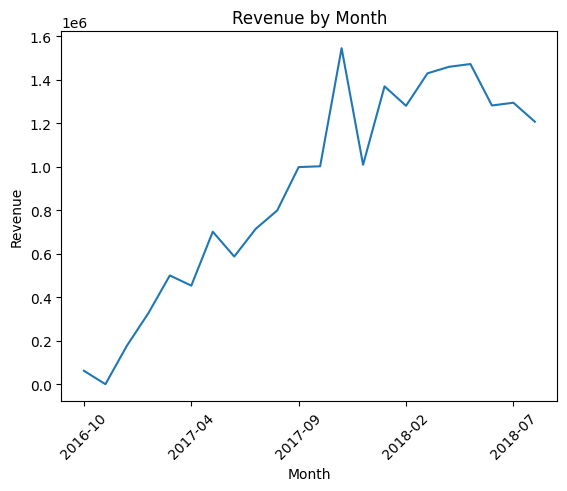

In [53]:


df_clean.groupby('month')['payment_value'].sum().plot()

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

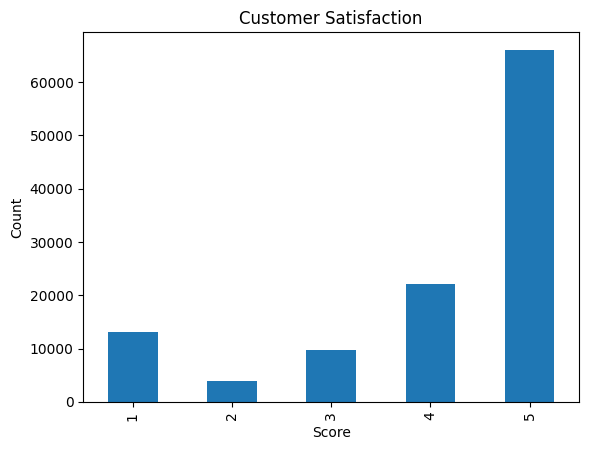

In [54]:
df_clean['review_score'].value_counts().sort_index().plot(kind='bar')

plt.title("Customer Satisfaction")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

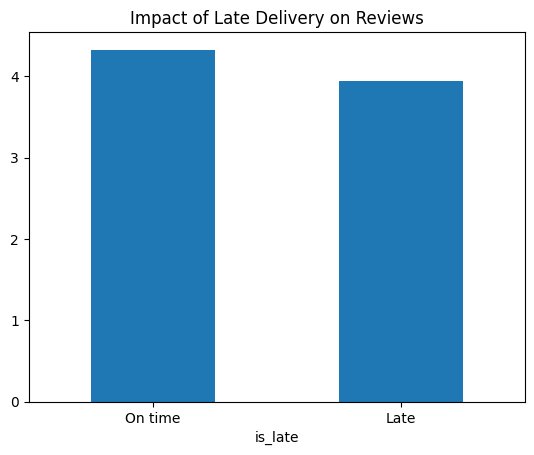

In [55]:
df_clean.groupby('is_late')['review_score'].mean().plot(kind='bar')

plt.title("Impact of Late Delivery on Reviews")
plt.xticks([0,1], ['On time', 'Late'], rotation=0)
plt.show()

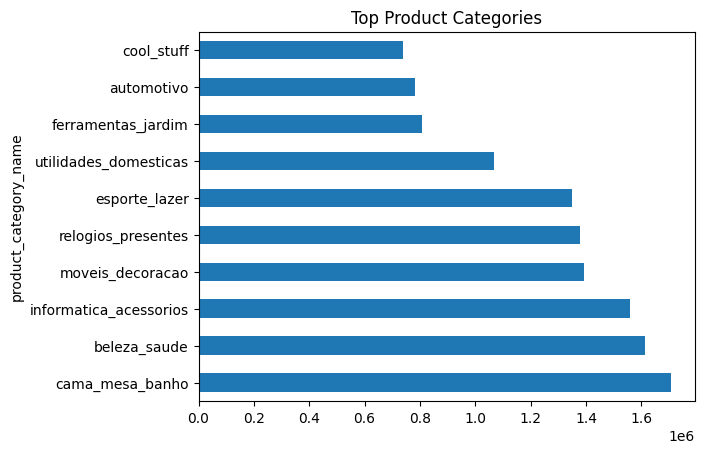

In [56]:
df_clean.groupby('product_category_name')['payment_value'].sum() \
    .sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top Product Categories")
plt.show()

## Business Insights
The company revenue shows clear monthly seasonality, indicating demand fluctuations over time
Late deliveries negatively impact customer satisfaction scores
A small number of product categories generate the majority of revenue (Pareto effect)
Delivery delays are a key driver of low customer reviews.